In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

# Parsing traces into dataframes

In [7]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64 = error_type(None, np.float64)
f64_TO = error_type('T.O.', np.float64)

def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width']
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [f64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [8]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)
    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [19]:
import os
print(os.getcwd())

/Volumes/HomeX/ldm/work/CODD/experiments


# loading traces

In [14]:
exp1 = experiment_to_df_tsptw('../build/trace_triangle3_xf', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')

In [22]:
with pd.option_context('display.max_rows', None,):
    display(exp1)

,Bench,Width,Opt,nodes1,nodes2,P,D,Opt Time,Proof Time
0,AFG/rbg010a.tw,64,671.0,1,1,0,0,0.001,0.001
1,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.0,0.0
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.0
3,AFG/rbg016a.tw,64,938.0,1,1,0,0,0.0,0.0
4,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.0,0.001
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.0,0.0
6,AFG/rbg016b.tw,64,1305.0,471,471,69,211,0.003,0.055
7,AFG/rbg016b.tw,128,1304.0,694,694,102,183,0.005,0.072
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.015,0.015
9,AFG/rbg017.2.tw,64,852.0,4423,4510,298,957,0.013,0.656


In [ ]:
exp2 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_XFLD_coddlocal_final', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
exp3 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_XFLD_codd_final', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp4 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_didp_final', scale_opt=10000.0, opt_name='Opt', patterns=[r'(\S+)', f'T.O.|t: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time', 'Opt']], types_list=[[str],[f64_TO, i32]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = experiment_to_df_tsptw('tsptw_TO_1000s_realfixlocal_tri/tsptw_XFL_1000', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')
# exp2 = experiment_to_df_tsptw('tsptw_TO_1000s_realfixlocal_tri/tsptw_RFL_1000', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
# exp3 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_didp_1000', scale_opt=10000.0, opt_name='Opt_didp', patterns=[r'(\S+)', f't: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time_didp', 'Opt_didp']], types_list=[[str],[np.float64, np.int32]]); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')

# exp4 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_ddo_1000', labels_list=[['Bench', None],['Opt_ddo', None, None, None, None, None, 'Proof Time_ddo', None, None]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = exp1[exp1['Opt'].notna()]
# exp2 = exp2[exp2['Opt'].notna()]

In [ ]:
L = 0; R = 1
suffixes = ('_codd_dl', '_codd_cl', '_codd', '_didp')
exp1.columns = exp1.columns.map(lambda name: name+suffixes[0] if name not in ('Width', 'Bench') else name)
exp2.columns = exp2.columns.map(lambda name: name+suffixes[1] if name not in ('Width', 'Bench') else name)
exp3.columns = exp3.columns.map(lambda name: name+suffixes[2] if name not in ('Width', 'Bench') else name)
exp4.columns = exp4.columns.map(lambda name: name+suffixes[3] if name not in ('Width', 'Bench') else name)

merge = pd.merge(exp1, exp2, on=['Bench', 'Width'], how='inner').merge(exp3, on=['Bench', 'Width'], how='inner').merge(exp4, on=['Bench'], how='inner')
final = merge #merge[merge["Bench"].isin(triangular)]
#final[~final.notna()] = 'T.O.'
final

,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp
0,AFG/rbg010a.tw,8,671.0,155,155,1,4,0.0,0.003,671.0,...,0.006,671.0,26,26,2,0,0.001,0.004,0.001703,671.0
1,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.001,0.001,0.001703,671.0
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.0,0.0,0.001703,671.0
3,AFG/rbg016a.tw,8,938.0,20,20,0,0,0.0,0.002,938.0,...,0.003,938.0,11,11,0,0,0.0,0.002,0.003732,938.0
4,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.0,0.001,938.0,...,0.001,938.0,1,1,0,0,0.001,0.001,0.003732,938.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,toy/toy1.tw,128,14.0,1,1,0,0,0.0,0.0,14.0,...,0.0,14.0,1,1,0,0,0.0,0.0,0.000051,14.0
263,toy/toy1.tw,1024,14.0,1,1,0,0,0.0,0.0,14.0,...,0.0,14.0,1,1,0,0,0.0,0.0,0.000051,14.0
264,toy/toy2.tw,8,214748.3647,1,1,0,0,0.0,0.0,214748.3647,...,0.0,214748.3647,1,1,0,0,0.0,0.0,None,NaN
265,toy/toy2.tw,128,214748.3647,1,1,0,0,0.0,0.0,214748.3647,...,0.0,214748.3647,1,1,0,0,0.0,0.0,None,NaN


# compute average speedup across various widths

In [1016]:
def average_speedup(L, R, w, exclude_below_L=None):
    global final
    L_times = final[f'Proof Time{suffixes[L]}']
    R_times = final[f'Proof Time{suffixes[R]}']
    L_times = L_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]
    R_times = R_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]

    if exclude_below_L is not None:
        R_times = R_times[L_times >= exclude_below_L]        
        L_times = L_times[L_times >= exclude_below_L]

    speedup = R_times / L_times
    # print(speedup)
    speedup = speedup.astype(float).replace(np.inf, np.nan).dropna()

    avg = np.average(speedup)
    if avg >= 1:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]}  ')
    else:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]} ({1/avg:.2f}x slower)')
    #print(f'                = {avg:.2f}')
    # else:
    #     print(f'average slowdown = {1/avg}')
    #     print(f'                 = {1/avg:.2f}')

In [1017]:
for w in set(final['Width']):
    print(f'w={w}')
    average_speedup(0,1,w)
    average_speedup(0,2,w)
    average_speedup(0,3,w)
    print(f'ignoring {suffixes[L]} < 1s')
    average_speedup(0,1,w,exclude_below_L=1)
    average_speedup(0,2,w,exclude_below_L=1)
    average_speedup(0,3,w,exclude_below_L=1)
    print()

w=8
_codd_dl is 1.56x faster than _codd_cl  
_codd_dl is 0.20x faster than _codd (5.08x slower)
_codd_dl is 1.03x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 1.25x faster than _codd_cl  
_codd_dl is 0.09x faster than _codd (10.68x slower)
_codd_dl is 0.07x faster than _didp (13.58x slower)

w=1024
_codd_dl is 1.12x faster than _codd_cl  
_codd_dl is 0.11x faster than _codd (9.49x slower)
_codd_dl is 4.20x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 0.05x faster than _codd_cl (19.05x slower)
_codd_dl is 0.03x faster than _codd (38.87x slower)
_codd_dl is 0.04x faster than _didp (25.88x slower)

w=128
_codd_dl is 1.83x faster than _codd_cl  
_codd_dl is 0.10x faster than _codd (10.33x slower)
_codd_dl is 3.93x faster than _didp  
ignoring _codd_dl < 1s
_codd_dl is 0.04x faster than _codd_cl (25.14x slower)
_codd_dl is 0.03x faster than _codd (35.01x slower)
_codd_dl is 0.02x faster than _didp (47.48x slower)



# how many instances can each solver solve, at each width?

In [1018]:
for suffix in suffixes:
    print(f'# where {suffix} solved within timeout: ')
    print('\t'.join(f'w={w}' for w in set(final['Width'])))
    for w in set(final['Width']):
        print(f'{len(final[ (final[f"Proof Time{suffix}"]!="T.O.") & (final["Width"]==w) ])}', end='\t')
    print()

# where _codd_dl solved within timeout: 
w=8	w=1024	w=128
84	86	86	
# where _codd_cl solved within timeout: 
w=8	w=1024	w=128
85	86	86	
# where _codd solved within timeout: 
w=8	w=1024	w=128
85	87	86	
# where _didp solved within timeout: 
w=8	w=1024	w=128
87	87	87	


# how many instances where one solver times out and another solves

In [1019]:
def TO_solves(L,R):
    X_TO = final[(final[f'Proof Time{suffixes[L]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    R_TO = final[(final[f'Proof Time{suffixes[L]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    print(f'# where {suffixes[L]} TOs, {suffixes[R]} solves: {len(X_TO)}')
    print(f'# where {suffixes[R]} TOs, {suffixes[L]} solves: {len(R_TO)}\n')
TO_solves(0,1)
TO_solves(1,2)
TO_solves(0,2)
# TO_solves(1,3)

# where _codd_dl TOs, _codd_cl solves: 1
# where _codd_cl TOs, _codd_dl solves: 0

# where _codd_cl TOs, _codd solves: 2
# where _codd TOs, _codd_cl solves: 1

# where _codd_dl TOs, _codd solves: 3
# where _codd TOs, _codd_dl solves: 1



In [1020]:
final = final.dropna() #need NaN rows to compute above, but don't want for plots

# If a row appears in any of the following dataframes, two solvers gave different opt values

In [1021]:
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd_dl and Opt_codd_cl disagree:


,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp


In [1022]:
R=2
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd_dl and Opt_codd disagree:


,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp


In [1023]:
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_codd_dl and Opt_didp disagree:


,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp


In [1024]:
codd_dl_slower = final[final["Proof Time_codd_dl"] > final["Proof Time_didp"]][["Bench", "Width", "Proof Time_codd_dl", "Proof Time_didp"]]
# codd_dl_slower.to_csv('codd_dl_slower.csv')
codd_dl_slower

,Bench,Width,Proof Time_codd_dl,Proof Time_didp
0,AFG/rbg010a.tw,8,0.003,0.001703
6,AFG/rbg016b.tw,8,0.361,0.029153
7,AFG/rbg016b.tw,128,0.276,0.029153
8,AFG/rbg016b.tw,1024,0.069,0.029153
10,AFG/rbg017.2.tw,128,11.931,0.486632
11,AFG/rbg017.2.tw,1024,12.593,0.486632
114,Langevin/N40ft403.dat,8,0.022,0.008945
123,Langevin/N40ft406.dat,8,0.006,0.004015
168,Langevin/N60ft301.dat,8,0.014,0.00977
177,Langevin/N60ft304.dat,8,0.014,0.009646


# plots

In [1025]:
plt.rcParams['figure.figsize'] = [14,4]
def cum_plot(df, column, log=False, ep=1e-6, sort_by=0, title='', find_peaks=None, peak_time=1):
    s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    if sort_by is not None: df = df.sort_values(by=f'{column}{suffixes[sort_by]}')
    #print(df['Bench'])

    _,[ax1,ax2] = plt.subplots(1,2)

    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax1.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax1.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    ax1.set_xlabel('# of Experiments')
    ax1.set_ylabel(f'Cumulative {column} (log)' if log else f'Cumulative {column}')
    ax1.set_title(title)
    ax1.legend()
    
    Ys = np.array([df[f'{column}{suffix}'] for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax2.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax2.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])

    if find_peaks is not None:
        for i in find_peaks:
            Y = Ys[i]
            dY = np.diff(Y)
            peaks = np.where((dY[:-1] > 0) & (dY[1:] < 0) & (np.abs(Y[1:-1]-Ys[sort_by][1:-1]) > peak_time))[0] + 1 
            ax2.scatter(X[peaks],Y[peaks],marker='x')
            bad_instances = df.iloc[peaks][['Bench', f'Proof Time{suffixes[i]}']]
            if len(bad_instances) > 0:
                print(bad_instances)

    ax2.set_xlabel('# of Experiments')
    ax2.set_ylabel(f'{column} (log)' if log else f'{column}')
    ax2.set_title(title)
    ax2.legend()
    plt.show()

# proof time vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

                     Bench Proof Time_codd_dl
222  Langevin/N60ft409.dat              1.106
213  Langevin/N60ft406.dat              1.315
                     Bench Proof Time_codd_cl
207  Langevin/N60ft404.dat              1.461
213  Langevin/N60ft406.dat              2.101


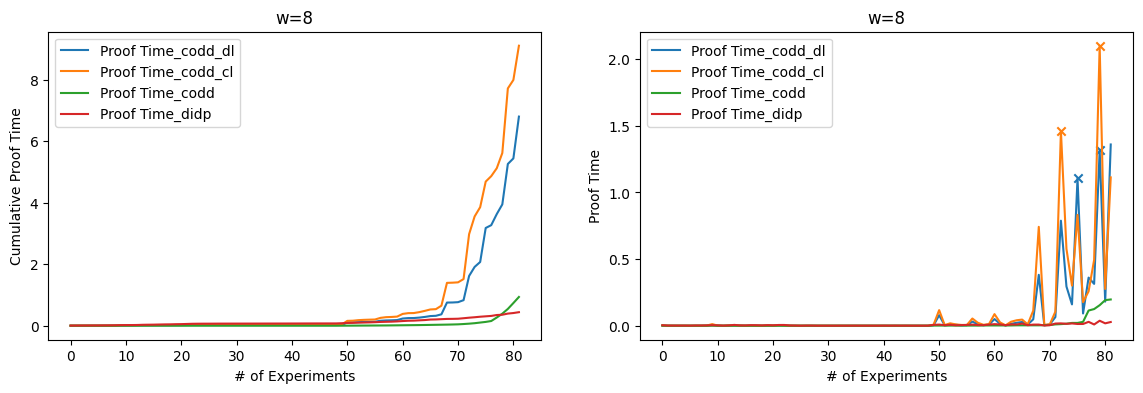

              Bench Proof Time_codd_dl
11  AFG/rbg017.2.tw             12.593


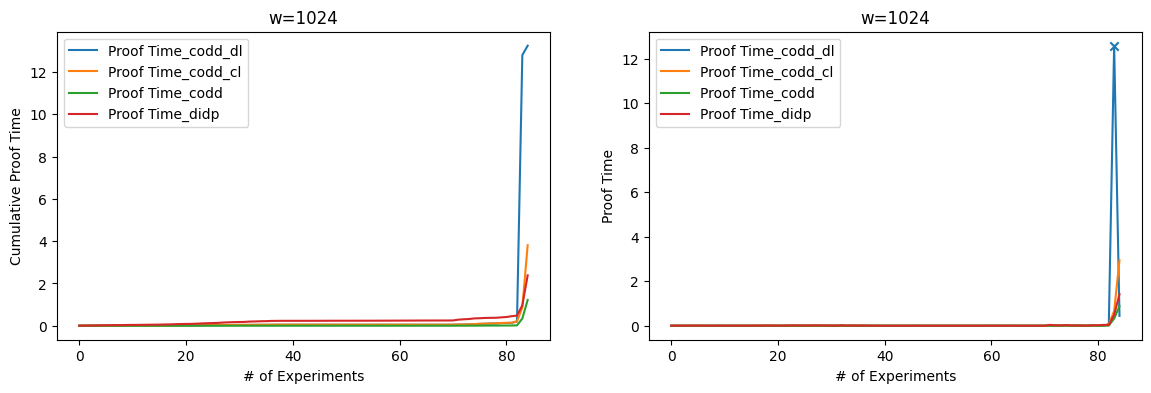

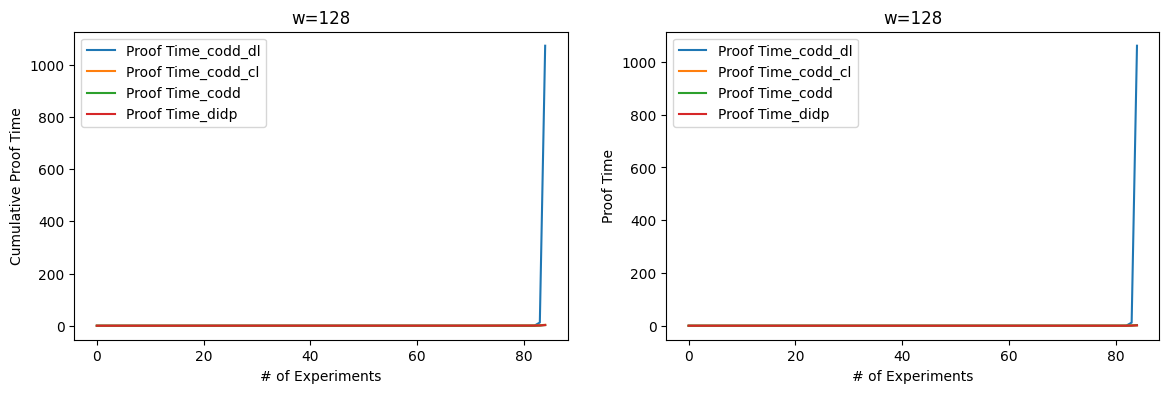

In [1026]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1,2,3], peak_time=1, title=f"w={w}")

# proof time vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

                     Bench Proof Time_codd_dl
222  Langevin/N60ft409.dat              1.106
213  Langevin/N60ft406.dat              1.315
                     Bench Proof Time_codd_cl
207  Langevin/N60ft404.dat              1.461
213  Langevin/N60ft406.dat              2.101


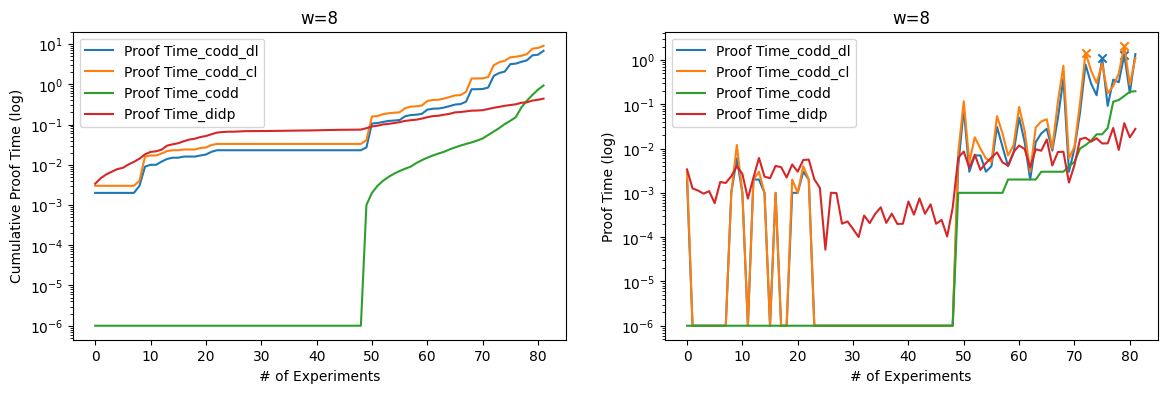

              Bench Proof Time_codd_dl
11  AFG/rbg017.2.tw             12.593


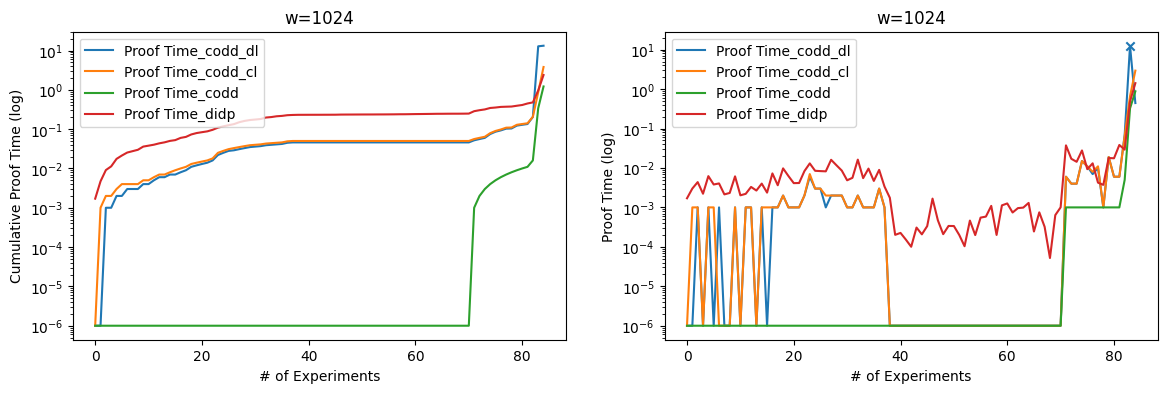

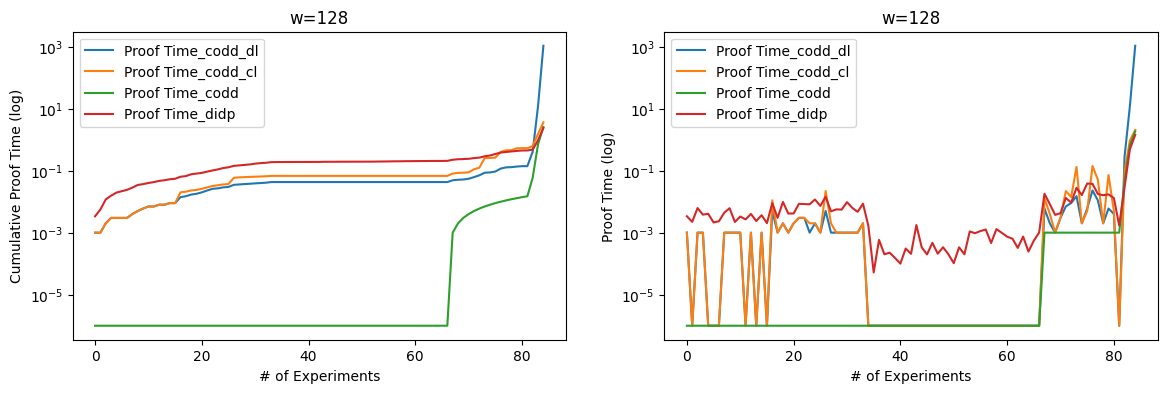

In [1027]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1,2,3], peak_time=1, title=f"w={w}", log=True)

# nodes vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

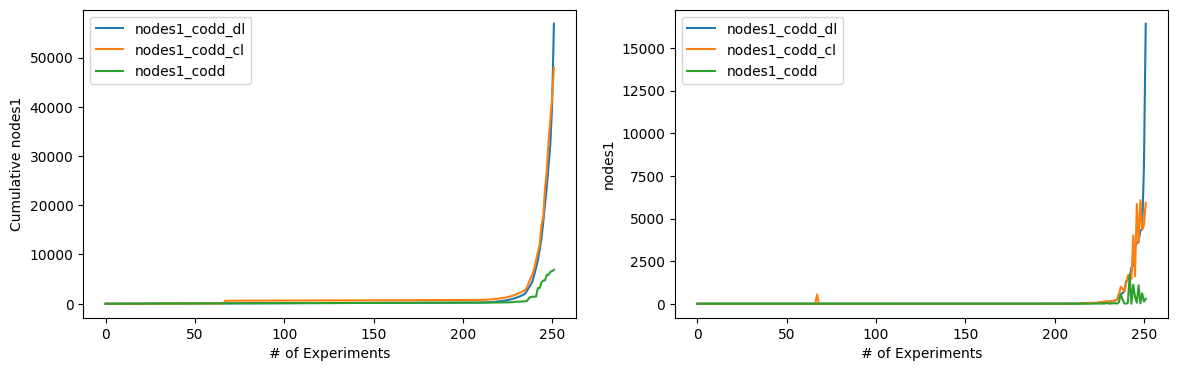

In [1028]:
cum_plot(final, 'nodes1')

# nodes vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

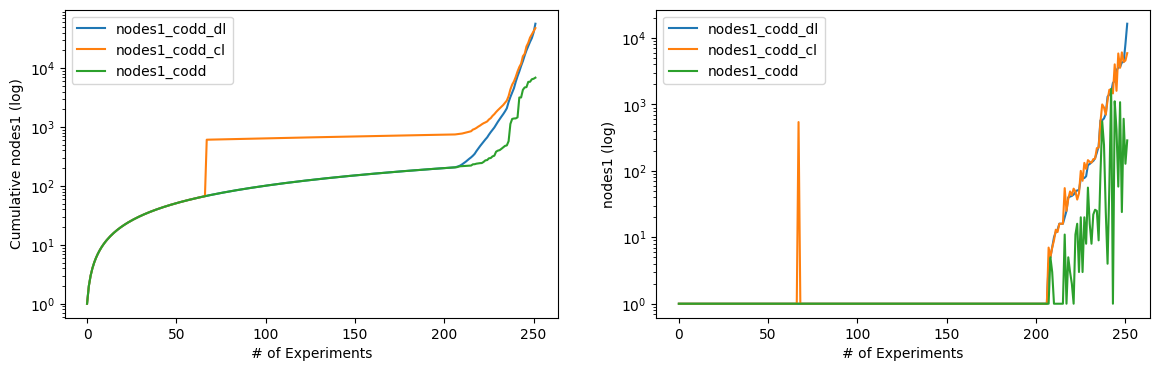

In [1029]:
cum_plot(final, 'nodes1', log=True)

# Playing around, no more analysis

In [1030]:
def valid_benches(exp, prefix='../data/tsptw'):
    return ' '.join([f'{prefix}/{x}' for x in exp1['Bench'].drop_duplicates()])

In [1031]:
exp = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal/tsptw_RFL_1000', scale_opt=10000.0); exp['Bench'] = exp['Bench'].str.split('/').str[-2:].str.join('/')
valid_benches(exp, prefix='./resources/tsptw')

'./resources/tsptw/AFG/rbg010a.tw ./resources/tsptw/AFG/rbg016a.tw ./resources/tsptw/AFG/rbg016b.tw ./resources/tsptw/AFG/rbg017.2.tw ./resources/tsptw/Dumas/n100w20.001.txt ./resources/tsptw/GendreauDumasExtended/n100w100.001.txt ./resources/tsptw/Langevin/N20ft301.dat ./resources/tsptw/Langevin/N20ft302.dat ./resources/tsptw/Langevin/N20ft303.dat ./resources/tsptw/Langevin/N20ft304.dat ./resources/tsptw/Langevin/N20ft305.dat ./resources/tsptw/Langevin/N20ft306.dat ./resources/tsptw/Langevin/N20ft307.dat ./resources/tsptw/Langevin/N20ft308.dat ./resources/tsptw/Langevin/N20ft309.dat ./resources/tsptw/Langevin/N20ft310.dat ./resources/tsptw/Langevin/N20ft401.dat ./resources/tsptw/Langevin/N20ft402.dat ./resources/tsptw/Langevin/N20ft403.dat ./resources/tsptw/Langevin/N20ft404.dat ./resources/tsptw/Langevin/N20ft405.dat ./resources/tsptw/Langevin/N20ft406.dat ./resources/tsptw/Langevin/N20ft407.dat ./resources/tsptw/Langevin/N20ft408.dat ./resources/tsptw/Langevin/N20ft409.dat ./resourc

In [1032]:
valid_benches(exp1)

'../data/tsptw/AFG/rbg010a.tw ../data/tsptw/AFG/rbg016a.tw ../data/tsptw/AFG/rbg016b.tw ../data/tsptw/AFG/rbg017.2.tw ../data/tsptw/Dumas/n100w20.001.txt ../data/tsptw/GendreauDumasExtended/n100w100.001.txt ../data/tsptw/Langevin/N20ft301.dat ../data/tsptw/Langevin/N20ft302.dat ../data/tsptw/Langevin/N20ft303.dat ../data/tsptw/Langevin/N20ft304.dat ../data/tsptw/Langevin/N20ft305.dat ../data/tsptw/Langevin/N20ft306.dat ../data/tsptw/Langevin/N20ft307.dat ../data/tsptw/Langevin/N20ft308.dat ../data/tsptw/Langevin/N20ft309.dat ../data/tsptw/Langevin/N20ft310.dat ../data/tsptw/Langevin/N20ft401.dat ../data/tsptw/Langevin/N20ft402.dat ../data/tsptw/Langevin/N20ft403.dat ../data/tsptw/Langevin/N20ft404.dat ../data/tsptw/Langevin/N20ft405.dat ../data/tsptw/Langevin/N20ft406.dat ../data/tsptw/Langevin/N20ft407.dat ../data/tsptw/Langevin/N20ft408.dat ../data/tsptw/Langevin/N20ft409.dat ../data/tsptw/Langevin/N20ft410.dat ../data/tsptw/Langevin/N40ft201.dat ../data/tsptw/Langevin/N40ft202.dat .

In [1033]:
final.head(20)

,Bench,Width,Opt_codd_dl,nodes1_codd_dl,nodes2_codd_dl,P_codd_dl,D_codd_dl,Opt Time_codd_dl,Proof Time_codd_dl,Opt_codd_cl,...,Proof Time_codd_cl,Opt_codd,nodes1_codd,nodes2_codd,P_codd,D_codd,Opt Time_codd,Proof Time_codd,Proof Time_didp,Opt_didp
0,AFG/rbg010a.tw,8,671.0,155,155,1,4,0.0,0.003,671.0,...,0.006,671.0,26,26,2,0,0.001,0.004,0.001703,671.0
1,AFG/rbg010a.tw,128,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.001,0.001,0.001703,671.0
2,AFG/rbg010a.tw,1024,671.0,1,1,0,0,0.0,0.0,671.0,...,0.0,671.0,1,1,0,0,0.0,0.0,0.001703,671.0
3,AFG/rbg016a.tw,8,938.0,20,20,0,0,0.0,0.002,938.0,...,0.003,938.0,11,11,0,0,0.0,0.002,0.003732,938.0
4,AFG/rbg016a.tw,128,938.0,1,1,0,0,0.0,0.001,938.0,...,0.001,938.0,1,1,0,0,0.001,0.001,0.003732,938.0
5,AFG/rbg016a.tw,1024,938.0,1,1,0,0,0.0,0.001,938.0,...,0.001,938.0,1,1,0,0,0.001,0.001,0.003732,938.0
6,AFG/rbg016b.tw,8,1304.0,3656,3677,465,1544,0.121,0.361,1304.0,...,0.258,1304.0,1082,1082,458,261,0.062,0.114,0.029153,1304.0
7,AFG/rbg016b.tw,128,1304.0,724,724,129,303,0.01,0.276,1304.0,...,0.092,1304.0,24,24,0,144,0.002,0.045,0.029153,1304.0
8,AFG/rbg016b.tw,1024,1304.0,1,1,0,0,0.069,0.069,1304.0,...,0.065,1304.0,1,1,0,0,0.005,0.005,0.029153,1304.0
10,AFG/rbg017.2.tw,128,852.0,16430,16430,1648,7610,0.013,11.931,852.0,...,0.926,852.0,288,288,0,447,0.001,0.661,0.486632,852.0


In [1034]:
numeric = final[final['Proof Time_RF'] != 'T.O.']
#numeric[numeric['Proof Time_XF'] >= 100]
numeric.sort_values(by='Proof Time_RF', ascending=False).head(4)

KeyError: 'Proof Time_RF'